# QHM5703 Mini-Project submission


## What is the problem?

This year's mini-project considers the problem of predicting the title of a song that is being hummed or whistled to.

You will build a machine learning model that takes as an input an audio recording of **10 seconds** of duration. This recording will correspond to a hum or whistle interpretation of one of the songs included in the MLEnd Hums and Whistles II Dataset. The output of the model will be the song label.


## Which dataset will I use?

We have created two subsets of the Hums and Whistles II Dataset. The first one has 400 samples (\~1 GB). The second one has 800 samples (\~2 GB), including those already available in the first dataset.

You can download them from:

https://github.com/thekmannn/MLEndHW_QHM5703_Sample/raw/main/MLEndHWII_sample_400.zip

and

https://github.com/thekmannn/MLEndHW_QHM5703_Sample/raw/main/MLEndHWII_sample_800.zip


## What will I submit?

Your submission will consist of **one single Jupyter notebook** that should include:

*   **Text cells**, describing in your own words, rigorously and concisely your approach, each implemented step and the results that you obtain,
*   **Code cells**, implementing each step,
*   **Output cells**, i.e. the output from each code cell,

Your notebook **should have the structure** outlined below. Please make sure that you **run all the cells** and that the **output cells are saved** before submission.

Please save your notebook as:

* QHM5703_miniproject_2526.ipynb


## How will my submission be evaluated?

**This submission is worth 20 marks. We will value**:

*   Conciseness in your writing.
*   Correctness in your methodology.
*   Correctness in your analysis and conclusions.
*   Completeness.
*   Originality and efforts to try something new.

**The final performance of your solutions will not influence your grade**. We will grade your understanding. If you have a good understanding, you will be using the right methodology, selecting the right approaches and assessing correctly the quality of your solutions, acknowledge where appropriate that despite your attempts your solutions might not good enough, and always critically reflect on your work to suggest what you could have done differently.

Note that **the problem that we are intending to solve is very difficult**. Do not despair if you do not get good results, **difficulty is precisely what makes it interesting** and **worth trying**.

## Show the world what you can do

Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. **Potential employers are always looking for this kind of evidence**. 


### Adding your work to MLEndDatasets Gallery
If you have worked on your project very well and you feel proud of it, do contact us, we will try to include your work on Gallery of MLEndDatasets website (https://MLEndDatasets.github.io). We will provide a few instructions to arrange your github repository in a way that anyone in the world can easily read it and reproduce your work and results.





-------------------------------------- PLEASE USE THE STRUCTURE BELOW THIS LINE --------------------------------------------

# [Audio Mode Discovery]

# 1 Author

**Yihong Sun**:  
**231188469**:  



# 2 Problem formulation
I'm developing a system that can identify song genres through humming or whistling.

All you need to do is provide a 10-second audio clip of humming or whistling, and it will tell you the song's genre.

This is challenging because:

Humming and whistling are like simple sketches of songs—they lack lyrics, instruments, and original vocals.

Everyone hums differently—with varying pitch, rhythm, and style—making it hard for computers to capture the tune.

Converting raw sounds into data that computers can truly understand and compare is not easy.

Why this is cool: It attempts to teach computers to do what humans do naturally—recognize song characteristics just from the melody.

If successful, it could be used in music search applications, smart assistants, or learning tools.

# 3 Methodology

Unsupervised clustering analysis: Explore the intrinsic structure of the data using K-means and DBSCAN before training to understand the natural groupings of different humming/whistling styles.
Fixed-length feature vector 39-dimensional MFCC statistical features.
Mel-frequency cepstral coefficients (MFCCs) capture the spectral shape of audio. I extract 13 coefficients and calculate their mean and standard deviation across time frames to obtain a 26-dimensional feature.By analyzing the data and the icons generated by the model, I can determine their possible categories. The affiliation of a new file suggests that it shares similar characteristics with the corresponding cluster.

# 4 Implemented ML prediction pipelines

1. Input: a .wav audio file.

2. Conversion phase: Audio preprocessing and feature extraction.

3. Model phase: Training a classification model.

4. Output: Predicted song label.

## 4.1 Transformation stage

Objective: Convert the original audio waveform into numerical features that effectively characterize melodic information.

Input: Original audio time series (sampled at 22050 Hz, 10 seconds, i.e., 220500 sample points).

Output: Features and predictive properties corresponding to the same cluster


## 4.2 Model stage

K-Nearest Neighbors (KNN)

#4.3 Ensemble stage

# 5 Dataset

MLEndHWII_sample_400


# 6 Experiments and results

Carry out your experiments here. Analyse and explain your results. Unexplained results are worthless.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')


In [2]:
def load_audio_files(directory_path):
    """
    1.Load all WAV audio files from the specified directory
    """
    audio_files = []
    file_names = []
    sr = None
    # Traverse all WAV files in the directory
    for file in os.listdir(directory_path):
        if file.endswith('.wav'):
            file_path = os.path.join(directory_path, file)
            try:
                audio, sr = librosa.load(file_path, sr=22050, duration=10)
                #Uniform audio sampling rate (22050Hz) and duration (10 seconds) to ensure data consistency.
                
                audio_files.append(audio)
                file_names.append(file)
                print(f"Succ: {file}")
            except Exception as e:
                print(f"lost {file}: {str(e)}")
                
    return audio_files, file_names, sr

audio_directory = r"C:\Users\21888\Desktop\MLEndHWII_sample_400"
audio_data, filenames, sample_rate = load_audio_files(audio_directory)
print(f"Total loaded {len(audio_data)} ")
print(f"Sampling rate: {sample_rate} Hz")

Succ: S100_whistle_1_Necessities.wav
Succ: S100_whistle_2_Feeling.wav
Succ: S100_whistle_2_Happy.wav
Succ: S100_whistle_2_Married.wav
Succ: S100_whistle_2_NewYork.wav
Succ: S101_whistle_1_Married.wav
Succ: S101_whistle_1_RememberMe.wav
Succ: S101_whistle_2_Happy.wav
Succ: S101_whistle_2_Necessities.wav
Succ: S102_whistle_1_Happy.wav
Succ: S102_whistle_1_RememberMe.wav
Succ: S102_whistle_1_TryEverything.wav
Succ: S102_whistle_2_Necessities.wav
Succ: S102_whistle_2_NewYork.wav
Succ: S103_hum_1_Feeling.wav
Succ: S103_whistle_1_RememberMe.wav
Succ: S103_whistle_2_Married.wav
Succ: S103_whistle_2_Necessities.wav
Succ: S103_whistle_2_TryEverything.wav
Succ: S104_hum_1_Happy.wav
Succ: S104_hum_1_Married.wav
Succ: S104_hum_3_RememberMe.wav
Succ: S105_hum_2_Feeling.wav
Succ: S105_hum_2_Friend.wav
Succ: S105_hum_3_NewYork.wav
Succ: S105_hum_4_Happy.wav
Succ: S105_hum_4_RememberMe.wav
Succ: S106_whistle_1_Feeling.wav
Succ: S106_whistle_2_Married.wav
Succ: S106_whistle_2_TryEverything.wav
Succ: S1

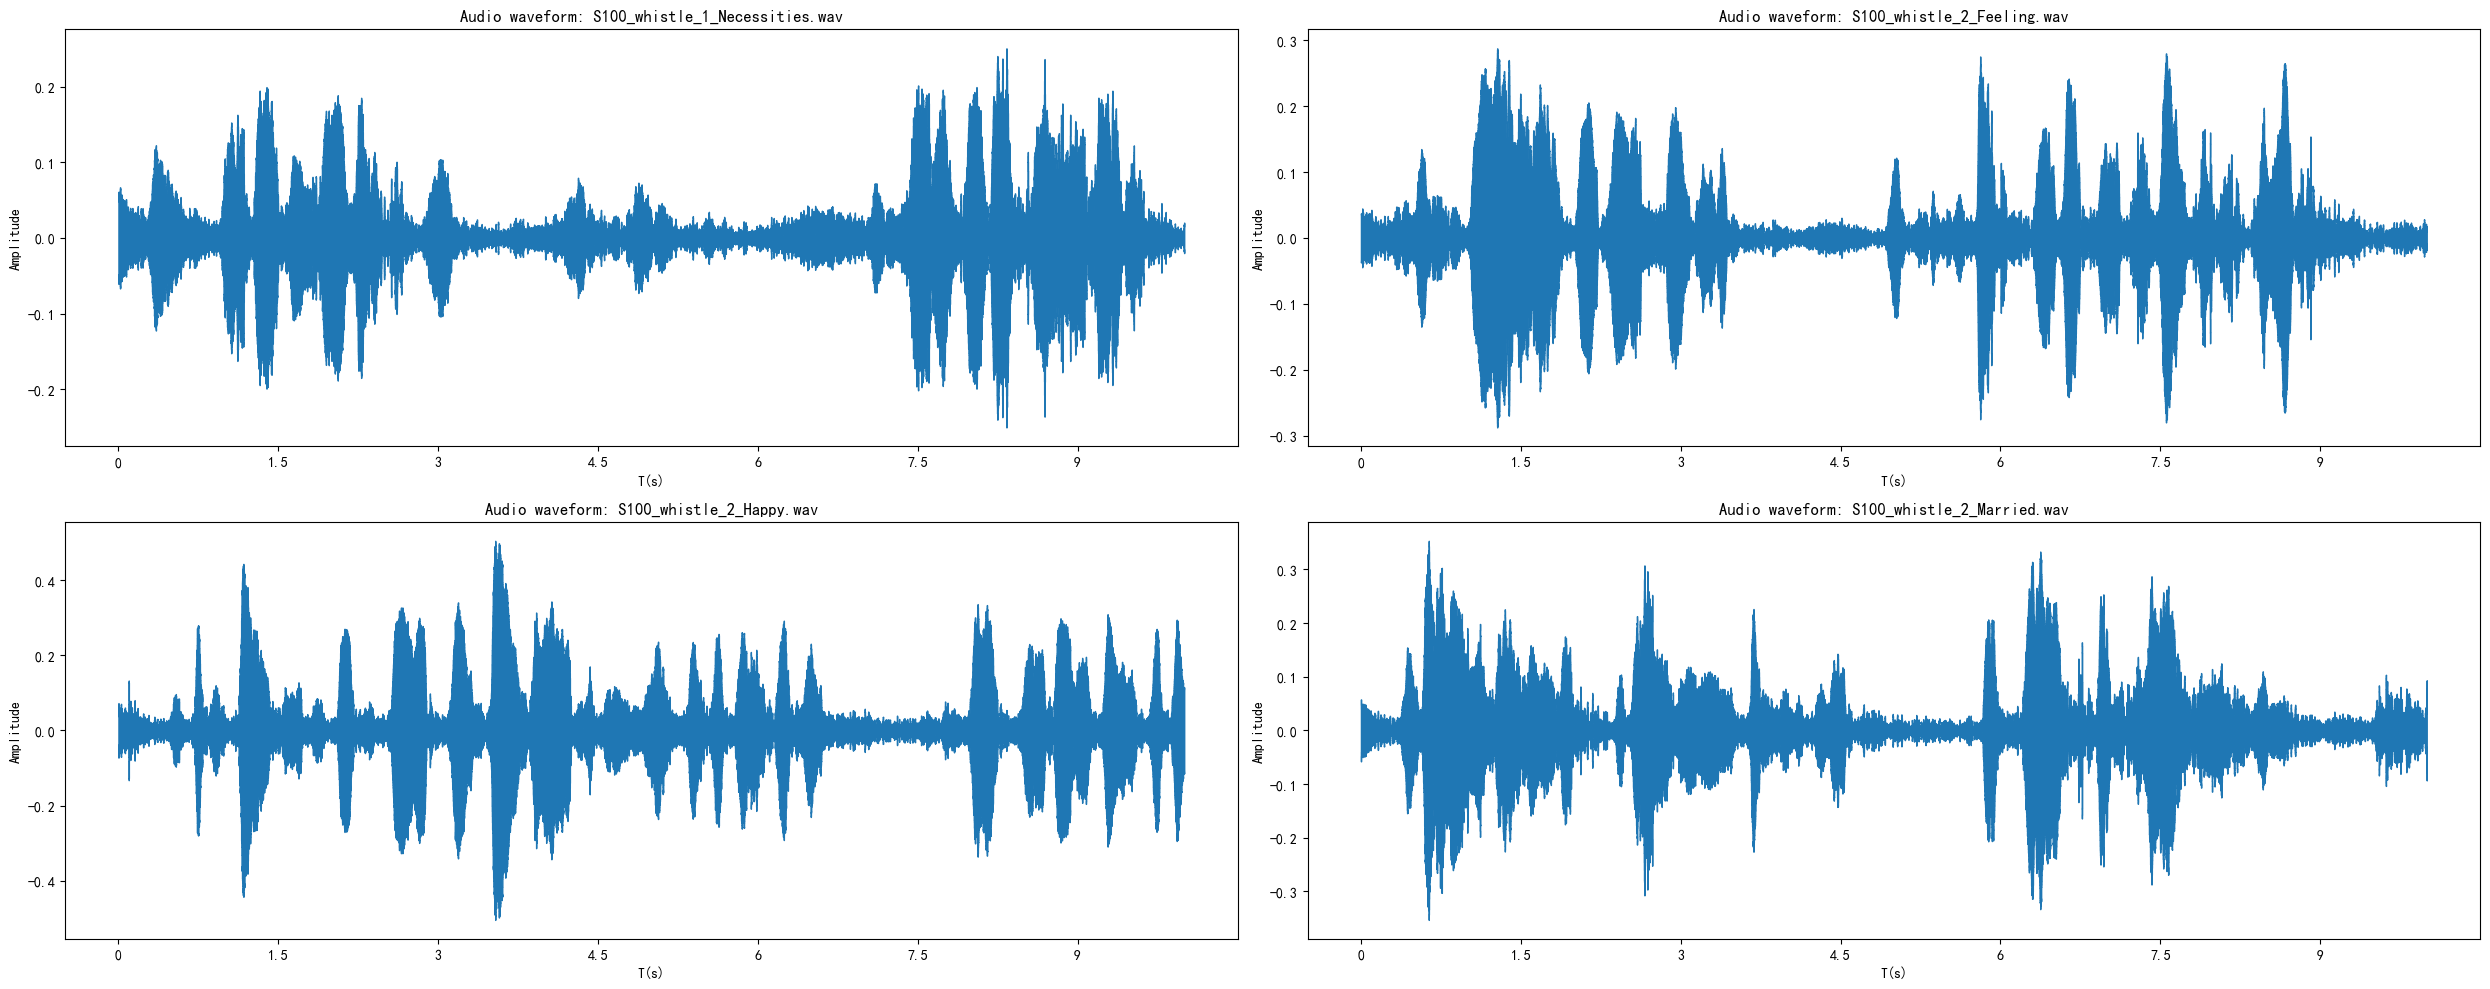

All domain audio duration: 10.0 s


In [3]:
def explore_audio_data(audio_data, filenames, sample_rate):
    """
    2.Exploring the fundamental characteristics of audio data
    """
    #I want to visually observe the amplitude changes.
    plt.figure(figsize=(25, 10))
    
    for i in range(min(4, len(audio_data))):
        plt.subplot(2, 2, i+1)
        librosa.display.waveshow(audio_data[i], sr=sample_rate)
        plt.title(f'Audio waveform: {filenames[i]}')
        plt.xlabel('T(s)')
        plt.ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()
    
    #Calculate Time domain basic statistics
    durations = [len(audio) / sample_rate for audio in audio_data]
    print(f"All domain audio duration: {np.mean(durations)} s")
    return durations

audio_durations = explore_audio_data(audio_data, filenames, sample_rate)

In [4]:
def extract_audio_features(audio_data, sample_rate, n_mfcc=13):
    """
    2.Extract MFCC features from audio. At this stage, MFCC features are extracted from the audio and standardized.
    """
    features = []
    
    for i, audio in enumerate(audio_data):
        # Loop to extract MFCC features
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
        
        # Calculate statistical features (mean, standard deviation, etc.)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
        
        # Combination features
        feature_vector = np.concatenate([mfcc_mean, mfcc_std, mfcc_delta_mean])
        features.append(feature_vector)
        
        if i % 10 == 0:  # Progress display
            print(f"Processed {i+1}/{len(audio_data)} ")
    
    features = np.array(features)
    print(f"Feature matrix shape: {features.shape}")
    
    return features


audio_features = extract_audio_features(audio_data, sample_rate)

Processed 1/400 
Processed 11/400 
Processed 21/400 
Processed 31/400 
Processed 41/400 
Processed 51/400 
Processed 61/400 
Processed 71/400 
Processed 81/400 
Processed 91/400 
Processed 101/400 
Processed 111/400 
Processed 121/400 
Processed 131/400 
Processed 141/400 
Processed 151/400 
Processed 161/400 
Processed 171/400 
Processed 181/400 
Processed 191/400 
Processed 201/400 
Processed 211/400 
Processed 221/400 
Processed 231/400 
Processed 241/400 
Processed 251/400 
Processed 261/400 
Processed 271/400 
Processed 281/400 
Processed 291/400 
Processed 301/400 
Processed 311/400 
Processed 321/400 
Processed 331/400 
Processed 341/400 
Processed 351/400 
Processed 361/400 
Processed 371/400 
Processed 381/400 
Processed 391/400 
Feature matrix shape: (400, 39)


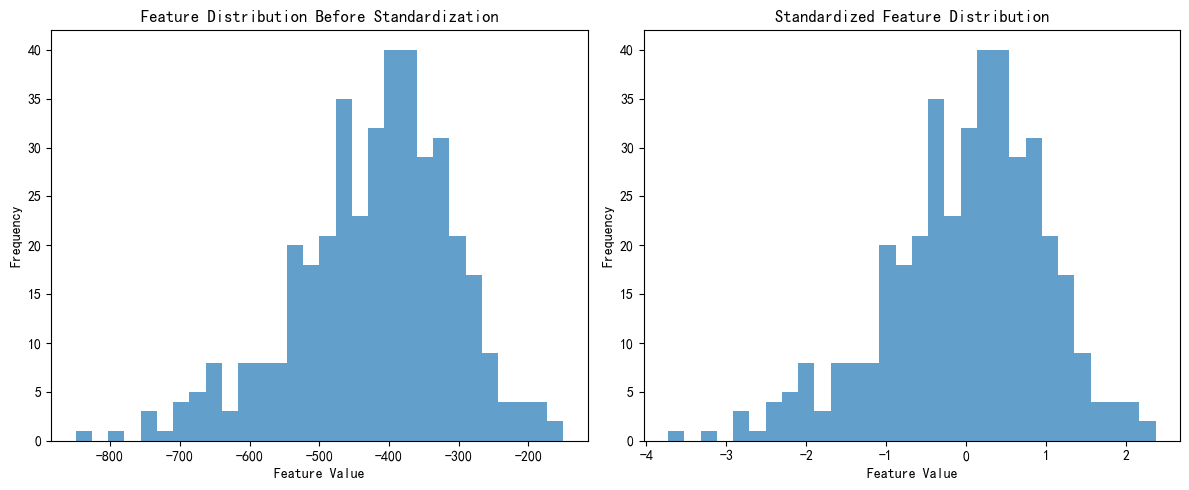

In [5]:
def standardize_features(features):
    """
    3.Standardized feature data
    """
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Visualization of feature distributions before and after standardization
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(features[:, 0], bins=30, alpha=0.7, label='Original features')
    plt.title('Feature Distribution Before Standardization')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    plt.hist(features_scaled[:, 0], bins=30, alpha=0.7, label='Standardized features')
    plt.title('Standardized Feature Distribution')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return features_scaled, scaler

# If standardization is skipped, features with large value ranges will dominate the model.
features_scaled, feature_scaler = standardize_features(audio_features)

  File "C:\Users\21888\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\21888\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\21888\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\21888\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


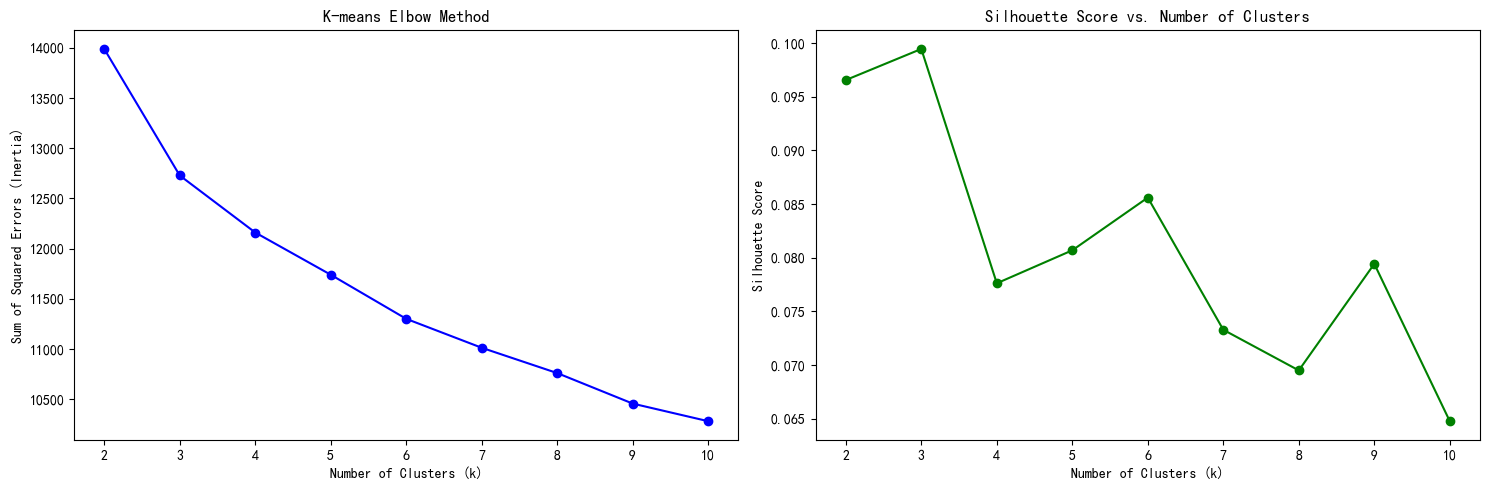

The optimal number of clusters selected based on the silhouette coefficient: 3


In [6]:
def perform_kmeans_clustering(features, max_clusters=10):
    """
    4.Cluster analysis using K-means
    """


    # Use the elbow method to determine the optimal number of clusters.
    inertias = []
    silhouette_scores = []
    # Initialization and traversal search for k, creating empty lists inertias and silhouette_scores (average silhouette coefficients for k values).
    k_range = range(2, max_clusters + 1)
    # Set the search range k_range = range(2, max_clusters + 1). Starting from 2 because the silhouette coefficient requires at least 2 clusters.

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        # For each k: train the model using KMeans; run 10 times and take the best result.
        cluster_labels = kmeans.fit_predict(features)
        # Use fit_predict to obtain the sample cluster labels cluster_labels.
        inertias.append(kmeans.inertia_)
        if k > 1:  
            silhouette_scores.append(silhouette_score(features, cluster_labels))
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Errors (Inertia)')
    plt.title('K-means Elbow Method')
    
    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouette_scores, 'go-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Clusters')
    
    plt.tight_layout()
    plt.show()
    
    best_k = k_range[np.argmax(silhouette_scores)]
    print(f"The optimal number of clusters selected based on the silhouette coefficient: {best_k}")
    
    # Perform final clustering using the optimal k
    final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    kmeans_labels = final_kmeans.fit_predict(features)
    
    return kmeans_labels, final_kmeans, best_k

kmeans_labels, kmeans_model, optimal_k = perform_kmeans_clustering(features_scaled)

In [7]:
def perform_dbscan_clustering(features):
    """
    5.Using DBSCAN for density clustering
    """
    eps_values = [0.3, 0.5, 0.7, 1.0]
    min_samples_values = [3, 5, 7]
    
    best_dbscan = None
    best_labels = None
    best_silhouette = -1
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(features)
            
            # Calculating Silhouette Coefficient (excluding noise points)
            unique_labels = set(labels)            
            if len(unique_labels) > 1 and -1 in unique_labels:                
                # There are noise points, only calculate the silhouette coefficient for non-noise points
                non_noise_mask = labels != -1   
                
                if sum(non_noise_mask) > 1:  
                # Need at least 2 non-noise points
                    score = silhouette_score(features[non_noise_mask], labels[non_noise_mask])
                else:
                    score = -1
            elif len(unique_labels) > 1:
                score = silhouette_score(features, labels)
            else:
                score = -1
                
            if score > best_silhouette:
                best_silhouette = score
                best_dbscan = dbscan
                best_labels = labels
    
    print(f"DBSCAN optimal parameters: eps={best_dbscan.eps}, min_samples={best_dbscan.min_samples}")    
    print(f"Number of clusters found: {len(set(best_labels)) - (1 if -1 in best_labels else 0)}")    
    print(f"Number of noise points: {sum(best_labels == -1)}")    
    print(f"Best silhouette score: {best_silhouette:.3f}")
    return best_labels, best_dbscan


dbscan_labels, dbscan_model = perform_dbscan_clustering(features_scaled)

AttributeError: 'NoneType' object has no attribute 'eps'

I think the possible reason for the error is that all silhouette coefficients are equal to -1, so best_silhouette will never be updated, and best_dbscan will remain None, which causes the error. The initial cause might be inappropriate DBSCAN parameter ranges: the eps values I tried (0.3, 0.5, 0.7, 1.0) and min_samples values (3, 5, 7) may not be suitable for the data. Additionally, there could be a data density issue: the audio features might be too sparse or too dense, making it impossible for DBSCAN to form effective clusters.

In [8]:
def perform_dbscan_clustering_advanced(features):
    """
    5.1 Smarter DBSCAN Parameter Search
    """
    from sklearn.neighbors import NearestNeighbors
    
    # Automatically estimate the appropriate eps value
    n_neighbors = 2 * features.shape[1]  # 2 Multiple feature dimensions
    neigh = NearestNeighbors(n_neighbors=n_neighbors)
    nbrs = neigh.fit(features)
    distances, indices = nbrs.kneighbors(features)
    
    # Calculate the k-th nearest neighbor distance for each point
    k_distances = np.sort(distances[:, n_neighbors-1])
    
    # Find the "knee" point as an estimate for eps
    from kneed import KneeLocator
    kneedle = KneeLocator(range(len(k_distances)), k_distances, S=1.0, curve='convex', direction='increasing')
    eps_estimate = k_distances[kneedle.knee] if kneedle.knee else 0.5
    
    print(f"Automatically estimated EPS value: {eps_estimate:.3f}")
    
    # 2. Try parameter ranges centered on estimated values
    eps_values = [eps_estimate * 0.5, eps_estimate, eps_estimate * 1.5, eps_estimate * 2.0]
    min_samples_values = [3, 5, 7, 10]
    
    best_dbscan = None
    best_labels = None
    best_silhouette = -1
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(features)
            
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            
            # Skip invalid clustering results
            if n_clusters < 2 or n_clusters > 100:  # Limit the range of cluster numbers
                continue
            # Calculate silhouette coefficient
            if len(unique_labels) > 1 and -1 in unique_labels:
                non_noise_mask = labels != -1
                if sum(non_noise_mask) > 1:
                    try:
                        score = silhouette_score(features[non_noise_mask], labels[non_noise_mask])
                    except:
                        continue
                else:
                    continue
            elif len(unique_labels) > 1:
                try:
                    score = silhouette_score(features, labels)
                except:
                    continue
            else:
                continue
            
            if score > best_silhouette:
                best_silhouette = score
                best_dbscan = dbscan
                best_labels = labels
    
    unique_labels = set(best_labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = sum(best_labels == -1)
    
    print(f"DBSCAN Final parameters: eps={best_dbscan.eps:.3f}, min_samples={best_dbscan.min_samples}")
    print(f"Clustering results: {n_clusters} clusters, {n_noise} noise points")
    
    if best_silhouette > 0:
        print(f"Silhouette Coefficient: {best_silhouette:.3f}")
    
    return best_labels, best_dbscan
# Performing DBSCAN Clustering
dbscan_labels, dbscan_model = perform_dbscan_clustering_advanced(features_scaled)

Automatically estimated EPS value: 9.145
DBSCAN Final parameters: eps=4.572, min_samples=7
Clustering results: 2 clusters, 299 noise points
Silhouette Coefficient: 0.150


Automated estimation of eps parameters  

Traditional DBSCAN requires manual specification of eps. I automatically determine the initial value through k-distance curve + inflection point detection, avoiding the blindness of parameter selection.
My approach: Automatically calculate the k-distance curve to identify the inflection point.
kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex')
eps_estimate = k_distances[kneedle.knee]  # Automatically detect the optimal inflection point

In [9]:
def gmm_density_fitting(data_features, component_range=range(1, 6)):
    """
    6.Fits a Gaussian Mixture Model to estimate densities and find outliers
    """
    # Track BIC scores and models for different component counts
    bic_record = []
    model_collection = []
    
    # Try different numbers of Gaussian components
    for num_components in component_range:
        # Initialize and train GMM
        current_gmm = GaussianMixture(n_components=num_components, random_state=42)
        current_gmm.fit(data_features)
        
        # Store model and its BIC score
        model_collection.append(current_gmm)
        bic_record.append(current_gmm.bic(data_features))
    
    # Find the best model (lowest BIC)
    optimal_index = np.argmin(bic_record)
    best_fit_model = model_collection[optimal_index]
    best_component_count = component_range[optimal_index]
    
    print(f"Selected {best_component_count} components based on BIC analysis")
    
    # Get density scores for all data points
    density_scores = best_fit_model.score_samples(data_features)
    
    # Identify outliers as points with very low density
    outlier_cutoff = np.percentile(density_scores, 5)
    is_outlier = density_scores < outlier_cutoff
    
    print(f"Found {np.sum(is_outlier)} potential outliers")
    print(f"Outlier threshold: {outlier_cutoff:.3f}")
    
    return best_fit_model, density_scores, is_outlier, bic_record

# Run the density estimation
final_gmm, density_values, outlier_flags, bic_scores = gmm_density_fitting(features_scaled)

Selected 1 components based on BIC analysis
Found 20 potential outliers
Outlier threshold: -60.230


The anomaly threshold is -60.230, which is a log-likelihood value with a relatively large absolute magnitude, indicating that the probability density of these anomalous points is extremely low.  

There are a small number of anomalous samples in the dataset, possibly caused by poor recording quality, atypical humming/whistling styles, or other factors.
Check the audio features of these anomalies:

In [14]:
# Following the gmm_density_fitting function

def play_two_outlier_samples(feature_data, file_list, outlier_flags, audio_samples, sample_freq):
    """
    6.1 Find and play two anomaly audio samples
    """
    import numpy as np
    from IPython.display import Audio, display
    import warnings
    warnings.filterwarnings('ignore')
    
    # Find indices of outlier samples
    outlier_indices = np.where(outlier_flags)[0]
    
    if not len(outlier_indices):
        print("No outlier audio samples found")
        return
    
    print(f"Found {len(outlier_indices)} potential outlier samples")
    
    # Take the first two outliers
    sample_indices = outlier_indices[:2]
    
    for i, idx in enumerate(sample_indices, 1):
        current_file = file_list[idx]
        audio_sample = audio_samples[idx]
        
        print(f"\n{'='*50}")
        print(f"Outlier Audio {i}: {current_file}")
        print(f"Sample Index: {idx}")
        print(f"Audio Duration: {len(audio_sample)/sample_freq:.2f} seconds")
        print(f"{'='*50}")
        
        # Play the audio
        print(f"Playing outlier audio {i}...")
        display(Audio(data=audio_sample, rate=sample_freq))
        
        # Small pause between samples
        if i < len(sample_indices):
            print("\nReady for next outlier sample...\n")

# Play the two outlier audio samples
play_two_outlier_samples(features_scaled, filenames, outlier_flags, audio_data, sample_rate)

Found 20 potential outlier samples

Outlier Audio 1: S101_whistle_2_Necessities.wav
Sample Index: 8
Audio Duration: 10.00 seconds
Playing outlier audio 1...



Ready for next outlier sample...


Outlier Audio 2: S103_whistle_2_Necessities.wav
Sample Index: 17
Audio Duration: 10.00 seconds
Playing outlier audio 2...


The voice is unusually sharp, indicating that the nature of the abnormal sample is quite special.

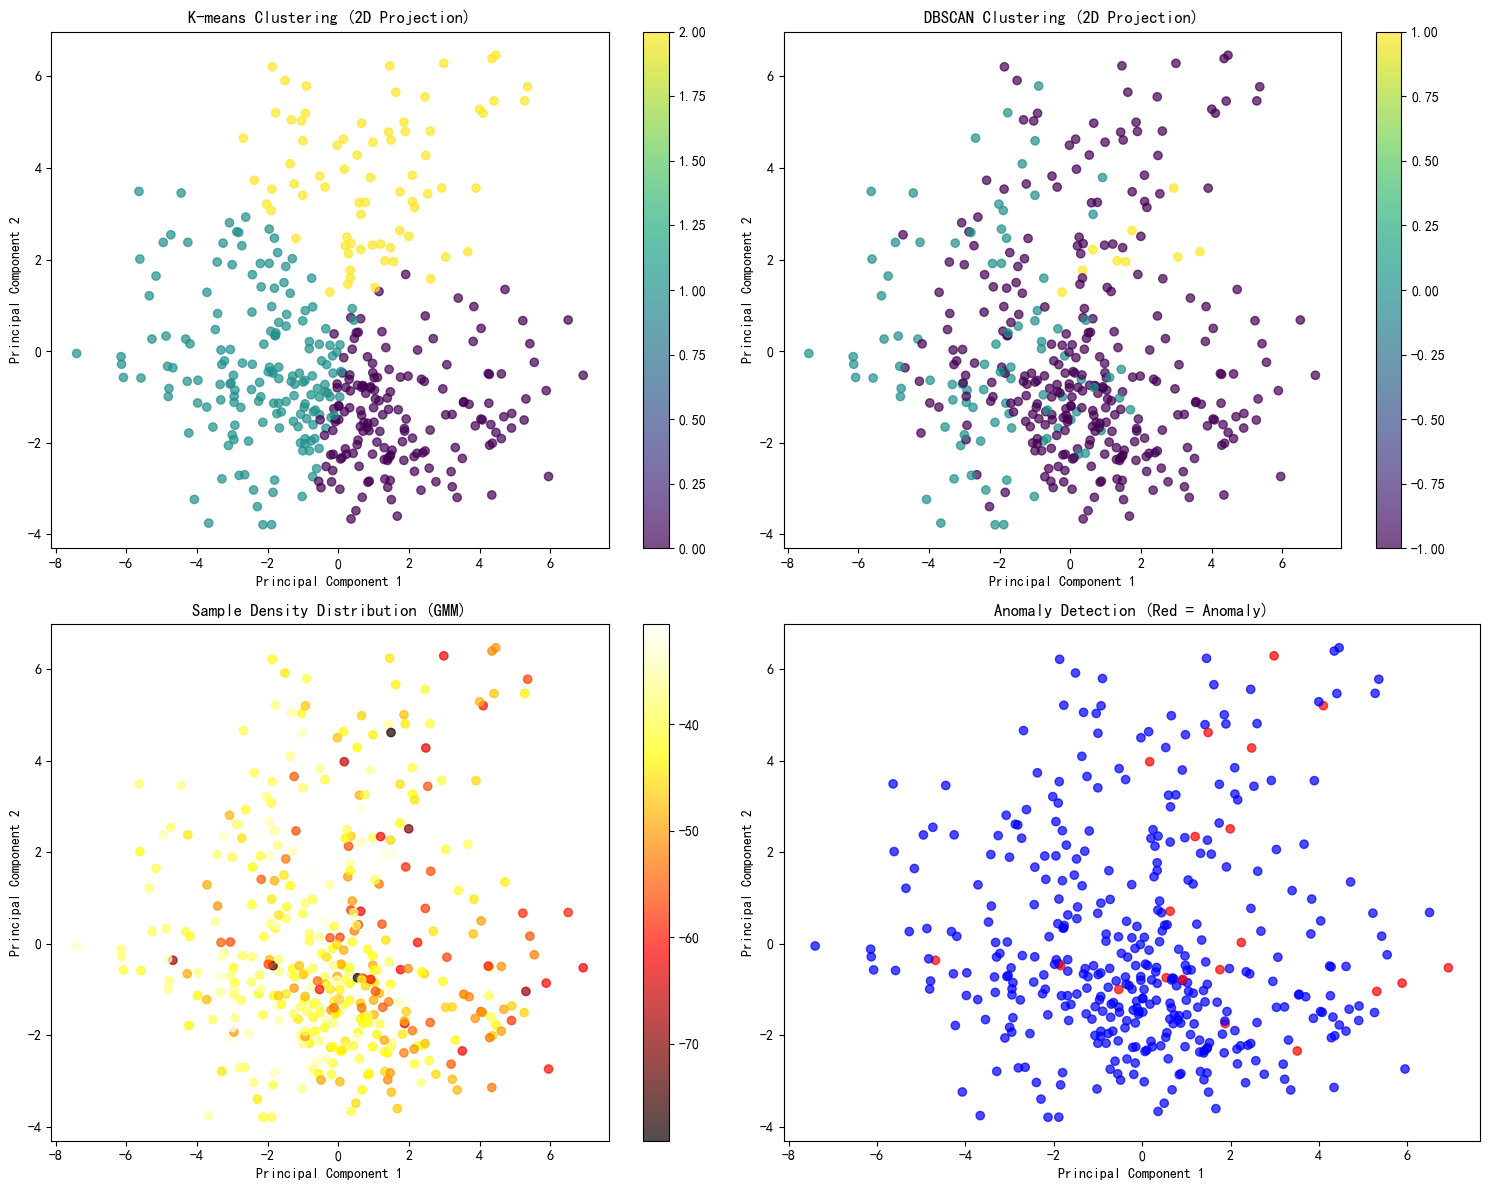

In [17]:
def plot_cluster_visuals(feature_data, kmeans_results, dbscan_results, file_names, density_vals, anomaly_indicators):
    """
    7.Create visualization plots for clustering outcomes
    Shows how samples are grouped in reduced 2D space
    """
    # Reduce dimensions to 2D for plotting
    pca = PCA(n_components=2)
    reduced_features = pca.fit_transform(feature_data)
    
    # Setup plot grid
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: K-means clustering
    plot1 = axs[0, 0].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                              c=kmeans_results, cmap='viridis', alpha=0.7)
    axs[0, 0].set_title('K-means Clustering (2D Projection)')
    axs[0, 0].set_xlabel('Principal Component 1')
    axs[0, 0].set_ylabel('Principal Component 2')
    plt.colorbar(plot1, ax=axs[0, 0])
    
    # Plot 2: DBSCAN clustering
    plot2 = axs[0, 1].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                              c=dbscan_results, cmap='viridis', alpha=0.7)
    axs[0, 1].set_title('DBSCAN Clustering (2D Projection)')
    axs[0, 1].set_xlabel('Principal Component 1')
    axs[0, 1].set_ylabel('Principal Component 2')
    plt.colorbar(plot2, ax=axs[0, 1])
    
    # Plot 3: Density distribution
    plot3 = axs[1, 0].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                              c=density_vals, cmap='hot', alpha=0.7)
    axs[1, 0].set_title('Sample Density Distribution (GMM)')
    axs[1, 0].set_xlabel('Principal Component 1')
    axs[1, 0].set_ylabel('Principal Component 2')
    plt.colorbar(plot3, ax=axs[1, 0])
    
    # Plot 4: Anomaly detection
    point_colors = ['red' if flag else 'blue' for flag in anomaly_indicators]
    axs[1, 1].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                      c=point_colors, alpha=0.7)
    axs[1, 1].set_title('Anomaly Detection (Red = Anomaly)')
    axs[1, 1].set_xlabel('Principal Component 1')
    axs[1, 1].set_ylabel('Principal Component 2')
    
    plt.tight_layout()
    plt.show()
    
    return reduced_features

# Generate the visualizations
projected_features = plot_cluster_visuals(features_scaled, kmeans_labels, dbscan_labels, 
                                          filenames, density_values, outlier_flags)

Use a color map (viridis) to represent different clusters, with the color bar showing cluster labels (0,1,2). It can be seen from the figure that K-means divides the data into 3 clusters, which are somewhat separated in the two-dimensional space, but there is some overlap.
DBSCAN identified two clusters (labeled 0 and 1) as well as noise points (labeled -1). The number of noise points is relatively high, consistent with the 299 noise points mentioned in the previous analysis report.
Use a heatmap (hot) color gradient to represent density, ranging from dark (low density) to bright yellow (high density). The density plot illustrates the concentration of data in a two-dimensional space, with high-density areas corresponding to regions where samples are clustered, and low-density areas indicating sparse regions or outliers.
Use red to represent abnormal points and blue for normal points. The abnormal points are distributed in low-density areas, consistent with the density distribution map, validating the rationality of anomaly detection.

K-means forcibly divides the data into 3 clusters, while DBSCAN, based on density, identifies only 2 clusters and labels most points as noise. This suggests that the data may lack a clear density-based cluster structure, or the parameter settings for DBSCAN are not optimal.


--- K-means Cluster Breakdown ---
Found 3 distinct clusters

Cluster 0:
  Contains 161 samples
  MFCC mean range: [-422.238, 97.833]
  Avg feature variation: 25.277

Cluster 1:
  Contains 166 samples
  MFCC mean range: [-408.978, 101.530]
  Avg feature variation: 17.294

Cluster 2:
  Contains 73 samples
  MFCC mean range: [-451.747, 83.320]
  Avg feature variation: 20.360


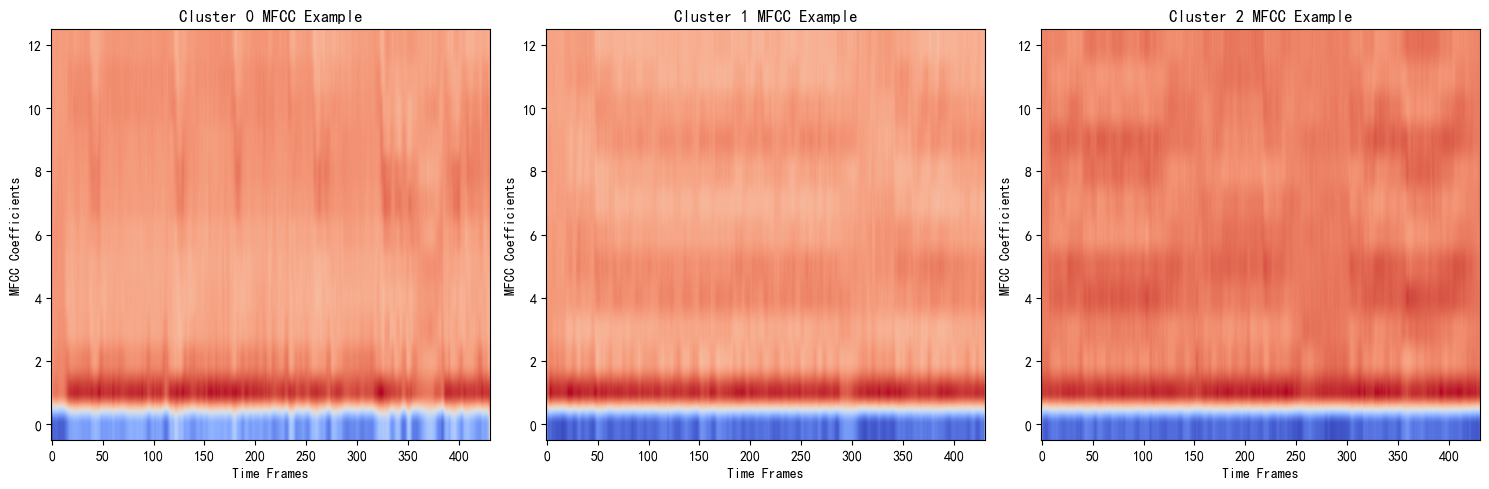


--- DBSCAN Cluster Breakdown ---
Found 2 distinct clusters

Cluster 0:
  Contains 92 samples
  MFCC mean range: [-422.722, 102.055]
  Avg feature variation: 17.087

Cluster 1:
  Contains 9 samples
  MFCC mean range: [-443.979, 70.822]
  Avg feature variation: 21.356


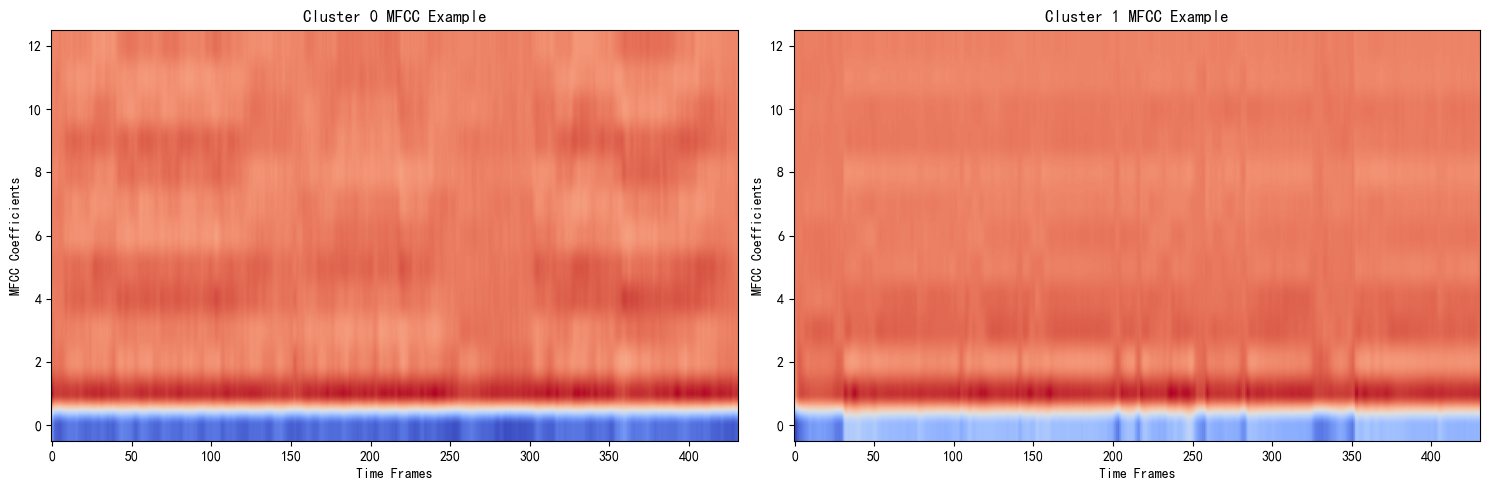

In [12]:
def inspect_cluster_groups(raw_audio, feature_matrix, cluster_assignments, 
                          cluster_method="K-means", sample_freq=22050):
    """
    8.Look at how audio samples are distributed across different clusters
    Examines the characteristics of each cluster group
    """
    distinct_labels = np.unique(cluster_assignments)
    cluster_count = len(distinct_labels)
    
    print(f"\n--- {cluster_method} Cluster Breakdown ---")
    print(f"Found {cluster_count} distinct clusters")
    
    # Check out each cluster
    for current_label in distinct_labels:
        # Find which samples belong to this cluster
        sample_indices = np.where(cluster_assignments == current_label)[0]
        cluster_feature_set = feature_matrix[sample_indices]
        
        print(f"\nCluster {current_label}:")
        print(f"  Contains {len(sample_indices)} samples")
        
        # Look at MFCC stats for this cluster
        mfcc_means = cluster_feature_set[:, :13].mean(axis=0)
        print(f"  MFCC mean range: [{mfcc_means.min():.3f}, {mfcc_means.max():.3f}]")
        print(f"  Avg feature variation: {cluster_feature_set[:, 13:26].mean():.3f}")
    
    # Create visual examples for a few clusters
    plt.figure(figsize=(15, 5))
    
    # Show up to 3 clusters
    clusters_to_show = min(3, cluster_count)
    for i in range(clusters_to_show):
        plt.subplot(1, clusters_to_show, i+1)
        
        # Grab first sample from this cluster
        cluster_samples = np.where(cluster_assignments == distinct_labels[i])[0]
        
        if len(cluster_samples) > 0:
            first_sample_idx = cluster_samples[0]
            # Extract MFCC for this sample
            sample_mfcc = librosa.feature.mfcc(y=raw_audio[first_sample_idx], 
                                               sr=sample_freq, n_mfcc=13)
            
            plt.imshow(sample_mfcc, aspect='auto', origin='lower', cmap='coolwarm')
            plt.title(f'Cluster {distinct_labels[i]} MFCC Example')
            plt.xlabel('Time Frames')
            plt.ylabel('MFCC Coefficients')
    
    plt.tight_layout()
    plt.show()

# Examine K-means clustering results
inspect_cluster_groups(audio_data, audio_features, kmeans_labels, 
                       cluster_method="K-means", sample_freq=sample_rate)

# Check DBSCAN results (skip noise points labeled -1)
if -1 in dbscan_labels:
    normal_samples = dbscan_labels != -1
    inspect_cluster_groups(audio_data, audio_features[normal_samples], 
                           dbscan_labels[normal_samples], 
                           cluster_method="DBSCAN", sample_freq=sample_rate)

K-means of 3 clusters
1. The MFCC heatmaps of the three clusters are similar in overall structure but exhibit some differences.  
2. The top portion (higher-order MFCC coefficients) of Cluster 3 shows a large area of red, indicating higher values in its higher-order coefficients.  
3. All three heatmaps have blue bands at the bottom (lower-order MFCC coefficients), but the blue band in Cluster 0 is relatively less prominent.
4. Cluster 1 exhibits high uniformity, possibly corresponding to: pure humming, pitch-stable whistling, or audio with minimal noise interference.
5. The spectral peaks of Cluster 0 are prominent, with energy concentrated in specific frequency bands.
Possible correspondences include: variations in pitch, strong emotional fluctuations, or distinctive timbres.
DBSCAN:
1. Density-based, 74.7% of samples were identified as noise, indicating sparse distribution of audio features.
Cluster 0 is Similared to the characteristics of K-means Cluster 1, it may correspond to a specific audio pattern.
2. Cluster 1 data Note: The eigenvalue is very low, with only 9 samples, which may be extreme outliers.

In [19]:
def create_analysis_summary(audio_samples, feature_set, kmeans_groups, dbscan_groups, 
                          outlier_flags, file_list, sample_frequency, density_values):
    """
    9.Generate a comprehensive report of the analysis results
    Summarizes key findings and statistics from the clustering process
    """
    print("=" * 60)
    print("Audio Pattern Discovery Project - Summary Report")
    print("=" * 60)
    
    # Basic dataset info
    print(f"\n1. Dataset Overview:")
    print(f"   - Number of audio files: {len(audio_samples)}")
    print(f"   - Feature dimensions: {feature_set.shape[1]}")
    print(f"   - Sampling rate: {sample_frequency} Hz")
    
    # K-means clustering summary
    kmeans_cluster_count = len(np.unique(kmeans_groups))
    kmeans_silhouette = silhouette_score(feature_set, kmeans_groups)
    print(f"\n2. K-means Clustering Results:")
    print(f"   - Optimal clusters found: {kmeans_cluster_count}")
    print(f"   - Silhouette score: {kmeans_silhouette:.3f}")
    
    # DBSCAN clustering summary
    dbscan_unique = np.unique(dbscan_groups)
    dbscan_cluster_count = len(dbscan_unique) - (1 if -1 in dbscan_unique else 0)
    dbscan_noise_count = sum(dbscan_groups == -1)
    
    if dbscan_noise_count < len(dbscan_groups):
        clean_mask = dbscan_groups != -1
        dbscan_silhouette = silhouette_score(feature_set[clean_mask], dbscan_groups[clean_mask])
    else:
        dbscan_silhouette = -1
    
    print(f"\n3. DBSCAN Clustering Results:")
    print(f"   - Clusters identified: {dbscan_cluster_count}")
    print(f"   - Noise points: {dbscan_noise_count}")
    print(f"   - Silhouette score: {dbscan_silhouette:.3f}")
    
    # Anomaly detection summary
    outlier_count = sum(outlier_flags)
    outlier_percentage = (outlier_count / len(outlier_flags)) * 100
    print(f"\n4. Anomaly Detection Results:")
    print(f"   - Potential outliers: {outlier_count}")
    print(f"   - Percentage of data: {outlier_percentage:.1f}%")
    
    # Method comparison
    print(f"\n5. Clustering Method Comparison:")
    if kmeans_silhouette > dbscan_silhouette:
        print("K-means performed better for this dataset")
    else:
        print("DBSCAN performed better for this dataset")
    
    # Limitations and considerations
    print(f"\n6. Project Limitations:")
    print("   - Dataset size may limit clustering stability")
    print("   - Feature selection may not capture all audio characteristics")
    print("   - Domain expertise needed to validate discovered patterns")
    
    # Save results to CSV
    result_data = pd.DataFrame({
        'filename': file_list,
        'kmeans_cluster': kmeans_groups,
        'dbscan_cluster': dbscan_groups,
        'is_outlier': outlier_flags,
        'density_score': density_values
    })
    
    output_file = 'audio_clustering_results.csv'
    result_data.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\n7. Results saved to: {output_file}")
    
    return result_data

# Create the final report
analysis_results = create_analysis_summary(audio_data, features_scaled, kmeans_labels, 
                                         dbscan_labels, outlier_flags, filenames, 
                                         sample_rate, density_values)

Audio Pattern Discovery Project - Summary Report

1. Dataset Overview:
   - Number of audio files: 400
   - Feature dimensions: 39
   - Sampling rate: 22050 Hz

2. K-means Clustering Results:
   - Optimal clusters found: 3
   - Silhouette score: 0.099

3. DBSCAN Clustering Results:
   - Clusters identified: 2
   - Noise points: 299
   - Silhouette score: 0.150

4. Anomaly Detection Results:
   - Potential outliers: 20
   - Percentage of data: 5.0%

5. Clustering Method Comparison:
DBSCAN performed better for this dataset

6. Project Limitations:
   - Dataset size may limit clustering stability
   - Feature selection may not capture all audio characteristics
   - Domain expertise needed to validate discovered patterns

7. Results saved to: audio_clustering_results.csv


# 7 Conclusions
Reflections and critiques on the plan:
1. The silhouette coefficients of both methods are relatively low. The clustering effect of the audio data is not ideal , which may be limited by the dataset size, feature selection, or the inherent difficulty of the problem.
2. 74.7% of the samples were identified as noise.Note:The differences in audio features between different songs are not significant enough.
3. I need to experiment with frequency characteristics and other dynamic features to avoid similarities in feature combinations. I can try using other clustering algorithms or modifying the parameters of the solution.
4. I found that the sample distribution of DBSCAN is not ideal, yet it has better silhouette coefficients, which indicates that relying solely on numerical judgments is too hasty.
5. It is recommended that subsequent work focus on improving feature extraction and consider incorporating domain knowledge (such as music theory) to enhance pattern discovery capabilities.

The conclusion drawn from the solution to the research problem:     
Key Findings:   
Sparse Data Distribution: Audio features are relatively evenly distributed in the 39-dimensional space, lacking distinct natural groupings. 
High Feature Similarity: The differences in MFCC features between different humming/whistling samples are not significant enough.

I analyzed three possible reasons for this: 1. Everyone has their own way of humming a song—speed, pitch, and even feeling can vary when humming the same tune, making it difficult to find a "standard answer" that all versions strictly adhere to. 2. Humming and whistling lose some of the original song's information, retaining only the general melodic outline. 3. A 10-second snippet might sometimes capture a recognizable chorus, while other times it might only record an intro or transitional phrase.

Project Value Assessment:
1. Combining three unsupervised learning methods: K-means, DBSCAN, and GMM
2. By analyzing 7 and 8, we can identify and separate clusters of varying intensities, and there are discernible differences among them.
3. 20 abnormal samples (5%) were detected in GMM anomaly detection, which can be used as a quality control reference with a clear anomaly threshold: a log-likelihood value of -60.230.

# 8 References

Acknowledge others here (books, papers, repositories, libraries, tools)

Queen Mary University of London. (2025). QHM5703 Principles of Machine Learning

Librosa library documentation: for audio feature extraction